# practice in class feature selection

In [15]:
pip install feature-engine

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# importing libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score, classification_report
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.preprocessing import PolynomialFeatures

In [18]:
# importing the data
adult = pd.read_csv("adult (1).csv")
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [19]:
print(adult.dtypes)

age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object


In [20]:
# preparing the data for modeling

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# gender to binary
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)

# replace ? with NaN
adult.replace("?", np.nan, inplace=True)

# impute missing values as average in numerical and "unknown" in categorical
for col in adult.columns:
    if adult[col].dtype == "object" or adult[col].dtype == "str":
        adult[col] = adult[col].fillna("unknown")
    else:
        adult[col] = adult[col].fillna(adult[col].median())
        
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,unknown,103497,Some-college,10,Never-married,unknown,Own-child,White,0,0,0,30,United-States,0


In [21]:
# Feature Preprocessing with Feature-engine

from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.model_selection import train_test_split

# copy data
df_fe = adult.copy()

# drop the fnlwgt variable as it is not useful for modeling
adult.drop(columns=["fnlwgt"], inplace=True)

# split features/target
X = df_fe.drop("income", axis=1)
y = df_fe["income"]

# split data
X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# identify variable types
cat_cols = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

# collapse rare categories
rare_encoder = RareLabelEncoder(
    tol=0.01,
    variables=cat_cols
)

X_train_fe = rare_encoder.fit_transform(X_train_fe)
X_test_fe = rare_encoder.transform(X_test_fe)

# frequency encode categorical variables
freq_encoder = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")

X_train_fe = freq_encoder.fit_transform(X_train_fe)
X_test_fe = freq_encoder.transform(X_test_fe)

# exclude problematic variables from discretization
disc_vars = [col for col in num_cols if col not in ["gender", "capital-gain", "capital-loss"]]

# discretize remaining numeric variables
disc = EqualFrequencyDiscretiser(
    q=5,
    variables=disc_vars
)

X_train_fe = disc.fit_transform(X_train_fe)
X_test_fe = disc.transform(X_test_fe)

# drop constant features if any were created
const_drop = DropConstantFeatures()

X_train_fe = const_drop.fit_transform(X_train_fe)
X_test_fe = const_drop.transform(X_test_fe)

print("Original shape:", X.shape)
print("Transformed train shape:", X_train_fe.shape)

X_train_fe.head(20)

C:\Users\prchandr\AppData\Local\Temp\1\ipykernel_29312\4033404195.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable workclass is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\f

Original shape: (48842, 14)
Transformed train shape: (39073, 14)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
34342,4,0.693727,0,0.324751,0,0.330945,0.042664,0.258618,0.85609,1,0,0,0,0.898344
18559,0,0.693727,4,0.028613,0,0.330945,0.113122,0.031352,0.85609,0,0,0,0,0.898344
12477,1,0.693727,0,0.324751,0,0.456632,0.101144,0.402580,0.85609,1,0,0,1,0.064699
560,3,0.693727,1,0.324751,0,0.031684,0.115067,0.105239,0.09513,0,0,0,1,0.898344
3427,1,0.693727,1,0.164257,2,0.456632,0.125278,0.402580,0.85609,1,0,0,1,0.898344
40152,0,0.693727,1,0.220920,1,0.330945,0.042664,0.154890,0.85609,1,0,0,0,0.898344
23445,0,0.056919,3,0.220920,1,0.330945,0.057175,0.154890,0.85609,0,0,0,0,0.898344
30132,3,0.693727,2,0.324751,0,0.456632,0.113122,0.402580,0.85609,1,0,0,1,0.898344
44628,3,0.029458,2,0.324751,0,0.330945,0.115067,0.105239,0.85609,0,0,0,1,0.898344
18571,0,0.693727,3,0.324751,0,0.330945,0.042664,0.154890,0.85609,0,0,1719,0,0.898344


In [29]:
from feature_engine.selection import DropConstantFeatures

const_drop = DropConstantFeatures()
X = const_drop.fit_transform(X)

In [31]:
print("Dropped constant features:", const_drop.features_to_drop_)

Dropped constant features: []


In [32]:
rare_encoder.encoder_dict_

{'workclass': ['Private',
  'unknown',
  'Federal-gov',
  'Local-gov',
  'State-gov',
  'Self-emp-not-inc',
  'Self-emp-inc',
  'Never-worked',
  'Without-pay'],
 'education': ['HS-grad',
  'Some-college',
  'Bachelors',
  'Masters',
  'Assoc-voc',
  '11th',
  'Assoc-acdm',
  '10th',
  '7th-8th',
  'Prof-school',
  '9th',
  '12th',
  'Doctorate',
  '5th-6th'],
 'marital-status': ['Never-married',
  'Married-civ-spouse',
  'Separated',
  'Divorced',
  'Widowed',
  'Married-AF-spouse',
  'Married-spouse-absent'],
 'occupation': ['Prof-specialty',
  'Craft-repair',
  'Exec-managerial',
  'Adm-clerical',
  'Sales',
  'Other-service',
  'Machine-op-inspct',
  'unknown',
  'Transport-moving',
  'Handlers-cleaners',
  'Farming-fishing',
  'Tech-support',
  'Protective-serv'],
 'relationship': ['Not-in-family',
  'Other-relative',
  'Husband',
  'Unmarried',
  'Own-child',
  'Wife'],
 'race': ['White',
  'Black',
  'Amer-Indian-Eskimo',
  'Other',
  'Asian-Pac-Islander'],
 'native-country': ['

### Baseline models with transformed original features

In [24]:
# baseline random forest and xgboost CV models using X_train_fe and X_test_fe datasets

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# baseline random forest with class imbalance handling and CV with default parameters
rf_baseline_fe = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cv_scores = cross_val_score(rf_baseline_fe, X_train_fe, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores:", rf_cv_scores)
rf_baseline_fe.fit(X_train_fe, y_train)
rf_preds_fe = rf_baseline_fe.predict(X_test_fe)
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))

# baseline xgboost with class imbalance handling and CV with default parameters

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos

xgb_baseline_fe = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores = cross_val_score(xgb_baseline_fe, X_train_fe, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost adult_fe CV Balanced Accuracy Scores:", xgb_cv_scores)    
xgb_baseline_fe.fit(X_train_fe, y_train)
xgb_preds_fe = xgb_baseline_fe.predict(X_test_fe)
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe)) 

Random Forest CV Balanced Accuracy Scores: [0.78021705 0.7968787  0.78316453 0.77404876 0.77759184]
Random Forest adult_fe Test Balanced Accuracy: 0.7834160676858406
XGBoost adult_fe CV Balanced Accuracy Scores: [0.8385879  0.84827002 0.84053737 0.8404516  0.83518103]
XGBoost adult_fe Test Balanced Accuracy: 0.8410927438622955


In [25]:
# Rank and display feature importances from baseline models using adult_fe data
rf_importances = pd.Series(rf_baseline_fe.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
xgb_importances = pd.Series(xgb_baseline_fe.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
print("Top 10 Random Forest Feature Importances:")
print(rf_importances.head(10))
print("\nTop 10 XGBoost Feature Importances:")
print(xgb_importances.head(10))


Top 10 Random Forest Feature Importances:
marital-status     0.170328
occupation         0.115161
age                0.110735
relationship       0.109766
capital-gain       0.092449
fnlwgt             0.081336
educational-num    0.066684
hours-per-week     0.060012
workclass          0.052172
education          0.051603
dtype: float64

Top 10 XGBoost Feature Importances:
marital-status     0.405946
educational-num    0.156355
capital-gain       0.116725
capital-loss       0.053215
age                0.049128
hours-per-week     0.044522
occupation         0.040687
education          0.028565
gender             0.025049
relationship       0.022311
dtype: float32


In [26]:
# Rank and display permutation importances for baseline models using adult_fe data

rf_perm_importance = permutation_importance(rf_baseline_fe, X_test_fe, y_test, n_repeats=10, random_state=42)
xgb_perm_importance = permutation_importance(xgb_baseline_fe, X_test_fe, y_test, n_repeats=10, random_state=42)

# saving permutation importance results in DataFrames for easier display
rf_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': rf_perm_importance.importances_mean,
    'importance_std': rf_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)
xgb_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': xgb_perm_importance.importances_mean,
    'importance_std': xgb_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

# display top 10 features by permutation importance for both models
print("Top 10 Random Forest Permutation Importances:")
print(rf_perm_importance_df.head(10))
print("\nTop 10 XGBoost Permutation Importances:")
print(xgb_perm_importance_df.head(10))

Top 10 Random Forest Permutation Importances:
            feature  importance_mean  importance_std
10     capital-gain         0.046381        0.001940
5    marital-status         0.021538        0.001839
4   educational-num         0.016583        0.002308
6        occupation         0.014495        0.002429
0               age         0.011721        0.002874
11     capital-loss         0.007575        0.000810
12   hours-per-week         0.006664        0.001711
1         workclass         0.002262        0.001916
2            fnlwgt         0.001269        0.002381
8              race        -0.000768        0.001002

Top 10 XGBoost Permutation Importances:
            feature  importance_mean  importance_std
10     capital-gain         0.048541        0.001456
5    marital-status         0.046259        0.002224
4   educational-num         0.014966        0.001739
11     capital-loss         0.010032        0.000785
6        occupation         0.009551        0.002092
0           

### Automatic Polynomial Feature Generation

In [27]:
# PolynomialFeatures on selected Feature-engine columns

X_train_poly_input = X_train_fe.copy()
X_test_poly_input = X_test_fe.copy()

poly = PolynomialFeatures(
    degree=3,
    interaction_only=True,
    include_bias=False
)

# fit on training data only
X_train_poly = poly.fit_transform(X_train_poly_input)

# transform test data using the same fitted transformer
X_test_poly = poly.transform(X_test_poly_input)

# feature names
poly_feature_names = poly.get_feature_names_out(X_train_poly_input.columns)

# convert back to DataFrames
X_train_poly_df = pd.DataFrame(
    X_train_poly,
    columns=poly_feature_names,
    index=X_train_poly_input.index
)

X_test_poly_df = pd.DataFrame(
    X_test_poly,
    columns=poly_feature_names,
    index=X_test_poly_input.index
)

print("Selected FE train shape:", X_train_poly_input.shape)
print("Expanded train shape:", X_train_poly_df.shape)
print("Selected FE test shape:", X_test_poly_input.shape)
print("Expanded test shape:", X_test_poly_df.shape)

X_train_poly_df.head()

Selected FE train shape: (39073, 14)
Expanded train shape: (39073, 469)
Selected FE test shape: (9769, 14)
Expanded test shape: (9769, 469)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,...,gender capital-gain capital-loss,gender capital-gain hours-per-week,gender capital-gain native-country,gender capital-loss hours-per-week,gender capital-loss native-country,gender hours-per-week native-country,capital-gain capital-loss hours-per-week,capital-gain capital-loss native-country,capital-gain hours-per-week native-country,capital-loss hours-per-week native-country
34342,4.0,0.693727,0.0,0.324751,0.0,0.330945,0.042664,0.258618,0.85609,1.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
18559,0.0,0.693727,4.0,0.028613,0.0,0.330945,0.113122,0.031352,0.85609,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
12477,1.0,0.693727,0.0,0.324751,0.0,0.456632,0.101144,0.402580,0.85609,1.0,...,0.0,0.0,0.0,0.0,0.0,0.064699,0.0,0.0,0.0,0.0
560,3.0,0.693727,1.0,0.324751,0.0,0.031684,0.115067,0.105239,0.09513,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3427,1.0,0.693727,1.0,0.164257,2.0,0.456632,0.125278,0.402580,0.85609,1.0,...,0.0,0.0,0.0,0.0,0.0,0.898344,0.0,0.0,0.0,0.0


# Filtering

In [ ]:
from feature_engine.selection import SmartCorrelatedSelection

# correlation filtering on polynomial features
corr_selector = SmartCorrelatedSelection(
    threshold=0.8,
    method="pearson",
    selection_method="model_performance",
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42)
)

X_train_poly_df = corr_selector.fit_transform(X_train_poly_df, y_train)
X_test_poly_df = corr_selector.transform(X_test_poly_df)

print("Polynomial feature shape after correlation filtering:", X_train_poly_df.shape)
print("Dropped correlated features:", corr_selector.features_to_drop_)

# Baseline Model

In [36]:
# baseline random forest and xgboost CV models using X_train_poly and X_test_poly datasets

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# baseline random forest with class imbalance handling and CV with default parameters
rf_baseline_poly = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cv_scores = cross_val_score(rf_baseline_poly, X_train_poly_df, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores:", rf_cv_scores)
rf_baseline_poly.fit(X_train_poly_df, y_train)
rf_preds_poly = rf_baseline_poly.predict(X_test_poly_df)
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))

# baseline xgboost with class imbalance handling and CV with default parameters

xgb_baseline_poly = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores = cross_val_score(xgb_baseline_poly, X_train_poly_df, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost CV Balanced Accuracy Scores:", xgb_cv_scores)    
xgb_baseline_poly.fit(X_train_poly_df, y_train)
xgb_preds_poly = xgb_baseline_poly.predict(X_test_poly_df)
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly)) 

Random Forest CV Balanced Accuracy Scores: [0.7751067  0.7867032  0.77409745 0.76562583 0.76934211]
Random Forest adult_poly Test Balanced Accuracy: 0.7762867482636664
XGBoost CV Balanced Accuracy Scores: [0.83089281 0.832659   0.83289625 0.82986791 0.8265467 ]
XGBoost adult_poly Test Balanced Accuracy: 0.8310996669789782


In [37]:
# Balanced Accuracy Scores for adult_fe and adult_poly datasets with baseline models
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly))

Random Forest adult_fe Test Balanced Accuracy: 0.7834160676858406
Random Forest adult_poly Test Balanced Accuracy: 0.7762867482636664
XGBoost adult_fe Test Balanced Accuracy: 0.8410927438622955
XGBoost adult_poly Test Balanced Accuracy: 0.8310996669789782


In [42]:
# feature importances from polynomial feature models
rf_importances_poly = pd.Series(rf_baseline_poly.feature_importances_, index=X_train_poly_df.columns).sort_values(ascending=False)
xgb_importances_poly = pd.Series(xgb_baseline_poly.feature_importances_, index=X_train_poly_df.columns).sort_values(ascending=False)
print("Top 20 Random Forest Feature Importances (Polynomial Features):")
print(rf_importances_poly.head(20))
print("\nTop 20 XGBoost Feature Importances (Polynomial Features):")
print(xgb_importances_poly.head(20))


Top 20 Random Forest Feature Importances (Polynomial Features):
marital-status native-country               0.033328
marital-status race native-country          0.022643
marital-status race                         0.021353
age marital-status hours-per-week           0.021215
age marital-status occupation               0.017053
age educational-num marital-status          0.016570
age marital-status                          0.014455
relationship                                0.014137
marital-status occupation                   0.014108
marital-status occupation native-country    0.011807
marital-status relationship gender          0.010703
age educational-num occupation              0.010483
marital-status                              0.008942
age relationship hours-per-week             0.008697
marital-status relationship                 0.008425
relationship gender                         0.008396
age educational-num relationship            0.008357
age marital-status relationship    

In [52]:
# FAST version of permutation importance

X_test_sample = X_test_poly_df.sample(n=1000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

rf_perm_importance_poly = permutation_importance(
    rf_baseline_poly,
    X_test_sample,
    y_test_sample,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

xgb_perm_importance_poly = permutation_importance(
    xgb_baseline_poly,
    X_test_sample,
    y_test_sample,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

# keep the same dataframe variable names used later
rf_perm_importance_poly_df = pd.DataFrame({
    'feature': X_test_sample.columns,
    'importance_mean': rf_perm_importance_poly.importances_mean,
    'importance_std': rf_perm_importance_poly.importances_std
}).sort_values(by='importance_mean', ascending=False)

xgb_perm_importance_poly_df = pd.DataFrame({
    'feature': X_test_sample.columns,
    'importance_mean': xgb_perm_importance_poly.importances_mean,
    'importance_std': xgb_perm_importance_poly.importances_std
}).sort_values(by='importance_mean', ascending=False)

print("Top 20 Random Forest Permutation Importances (Polynomial Features):")
print(rf_perm_importance_poly_df.head(20))
print("\nTop 20 XGBoost Permutation Importances (Polynomial Features):")
print(xgb_perm_importance_poly_df.head(20))

Top 20 Random Forest Permutation Importances (Polynomial Features):
                                           feature  importance_mean  \
112                           age workclass gender         0.001000   
10                                    capital-gain         0.001000   
258                fnlwgt education native-country         0.001000   
145             age educational-num hours-per-week         0.000667   
364              educational-num relationship race         0.000667   
62                    educational-num relationship         0.000667   
242                workclass gender native-country         0.000667   
308               education educational-num gender         0.000667   
119                      age fnlwgt marital-status         0.000667   
445       relationship capital-gain native-country         0.000333   
122                                age fnlwgt race         0.000333   
358                educational-num occupation race         0.000333   
384  educ

Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'age educational-num', 'age capital-gain',
       'age capital-loss', 'age hours-per-week',
       'educational-num capital-gain', 'educational-num capital-loss',
       'educational-num hours-per-week', 'capital-gain capital-loss',
       'capital-gain hours-per-week', 'capital-loss hours-per-week',
       'age educational-num capital-gain', 'age educational-num capital-loss',
       'age educational-num hours-per-week', 'age capital-gain capital-loss',
       'age capital-gain hours-per-week', 'age capital-loss hours-per-week',
       'educational-num capital-gain capital-loss',
       'educational-num capital-gain hours-per-week',
       'educational-num capital-loss hours-per-week',
       'capital-gain capital-loss hours-per-week'],
      dtype='object')

### Averaging feature importance and permutation importance rankings


In [59]:
# Averaging feature importance and permutation importance ranks by model for adult_poly data


# RF averaged rankings

# 1. Feature importance → DataFrame
rf_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": rf_baseline_poly.feature_importances_
})

# 2. Permutation importance already computed → rf_perm_importance_poly_df

# 3. Rank both
rf_feat_df["rank_feat"] = rf_feat_df["feat_importance"].rank(ascending=False)
rf_perm_importance_poly_df["rank_perm"] = rf_perm_importance_poly_df["importance_mean"].rank(ascending=False)

# 4. Merge
rf_combined = rf_feat_df.merge(
    rf_perm_importance_poly_df[["feature", "importance_mean", "rank_perm"]],
    on="feature"
)

# 5. Average ranks
rf_combined["rank_avg"] = (rf_combined["rank_feat"] + rf_combined["rank_perm"]) / 2

# 6. Sort
rf_combined = rf_combined.sort_values("rank_avg")

# display all columns in the combined DataFrame
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Top features
rf_top_features = rf_combined.head(75)

# XGB averaged rankings

# 1. Feature importance → DataFrame
xgb_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": xgb_baseline_poly.feature_importances_
})

# 2. Permutation importance already computed → xgb_perm_importance_poly_df

# 3. Rank both
xgb_feat_df["rank_feat"] = xgb_feat_df["feat_importance"].rank(ascending=False)
xgb_perm_importance_poly_df["rank_perm"] = xgb_perm_importance_poly_df["importance_mean"].rank(ascending=False)

# 4. Merge
xgb_combined = xgb_feat_df.merge(
    xgb_perm_importance_poly_df[["feature", "importance_mean", "rank_perm"]],
    on="feature"
)

# 5. Average ranks
xgb_combined["rank_avg"] = (xgb_combined["rank_feat"] + xgb_combined["rank_perm"]) / 2

# 6. Sort
xgb_combined = xgb_combined.sort_values("rank_avg")

# Top features
xgb_top_features = xgb_combined.head(20)

print("Top 20 RF Features")
print(rf_top_features.to_string(index=False))

print("\nTop 20 XGB Features")
print(xgb_top_features.to_string(index=False))

Top 20 RF Features
                                      feature  feat_importance  rank_feat  importance_mean  rank_perm  rank_avg
           age educational-num hours-per-week         0.006524       24.0         0.000667        6.5     15.25
                                 capital-gain         0.005900       30.0         0.001000        2.0     16.00
     marital-status occupation hours-per-week         0.006414       26.0         0.000333       17.0     21.50
                 educational-num relationship         0.003916       52.0         0.000667        6.5     29.25
              age relationship native-country         0.003540       59.0         0.000333       17.0     38.00
     occupation hours-per-week native-country         0.002920       91.0         0.000333       17.0     54.00
             race capital-gain native-country         0.002783       96.0         0.000333       17.0     56.50
              educational-num occupation race         0.002734      102.0         0.0

In [60]:
# reduced Random Forest and XGB datasets

X_train_rf_20 = X_train_poly_df[rf_top_features["feature"]]
X_test_rf_20  = X_test_poly_df[rf_top_features["feature"]]

X_train_xgb_20 = X_train_poly_df[xgb_top_features["feature"]]
X_test_xgb_20  = X_test_poly_df[xgb_top_features["feature"]]

### Validating how many features are ideal

   num_features  balanced_accuracy
0             5           0.802453
1            10           0.812371
2            15           0.830159
3            20           0.831195
4            25           0.830594
5            30           0.834874
6            35           0.838121
7            40           0.836076
8            45           0.839207
9            50           0.838020


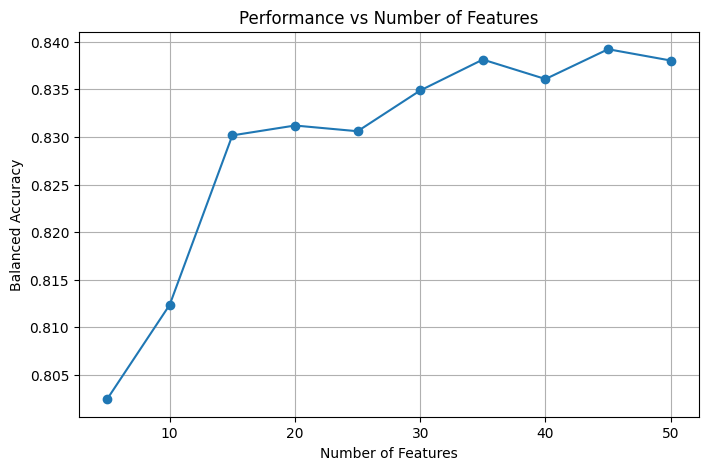

In [58]:
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt

ranked_features = xgb_combined.sort_values("rank_avg")["feature"].tolist()

results = []

for k in range(5, 51, 5):
    top_k = ranked_features[:k]

    X_train_k = X_train_poly_df[top_k]
    X_test_k = X_test_poly_df[top_k]

    model = XGBClassifier(
        scale_pos_weight=spw,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train_k, y_train)
    preds = model.predict(X_test_k)

    score = balanced_accuracy_score(y_test, preds)
    results.append((k, score))

results_df = pd.DataFrame(results, columns=["num_features", "balanced_accuracy"])
print(results_df)

plt.figure(figsize=(8, 5))
plt.plot(results_df["num_features"], results_df["balanced_accuracy"], marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Balanced Accuracy")
plt.title("Performance vs Number of Features")
plt.grid(True)
plt.show()

In [ ]:
# balanced accuracy scores for adult_fe and adult_poly and adult datasets
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))
print("Random Forest RF Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_rf_20))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly))
print("XGBoost XGB Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_xgb_20))

Random Forest adult_fe Test Balanced Accuracy: 0.7834160676858406
Random Forest adult_poly Test Balanced Accuracy: 0.7762867482636664
Random Forest RF Top 20 Test Balanced Accuracy: 0.7725787539057648
XGBoost adult_fe Test Balanced Accuracy: 0.8410927438622955
XGBoost adult_poly Test Balanced Accuracy: 0.8310996669789782
XGBoost XGB Top 20 Test Balanced Accuracy: 0.8311952713754681


In [64]:
# creating reduced datasets (20 features each)

X_train_rf_20 = X_train_poly_df[rf_top_features["feature"]]
X_test_rf_20 = X_test_poly_df[rf_top_features["feature"]]

X_train_xgb_20 = X_train_poly_df[xgb_top_features["feature"]]
X_test_xgb_20 = X_test_poly_df[xgb_top_features["feature"]]

print("RF top 20 train shape:", X_train_rf_20.shape)
print("RF top 20 test shape:", X_test_rf_20.shape)
print("XGB top 20 train shape:", X_train_xgb_20.shape)
print("XGB top 20 test shape:", X_test_xgb_20.shape)

RF top 20 train shape: (39073, 75)
RF top 20 test shape: (9769, 75)
XGB top 20 train shape: (39073, 20)
XGB top 20 test shape: (9769, 20)


In [65]:
# baseline Random Forest and XGBoost models on reduced datasets

rf_baseline_rf_20 = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cv_scores_rf_20 = cross_val_score(
    rf_baseline_rf_20,
    X_train_rf_20,
    y_train,
    cv=skf,
    scoring='balanced_accuracy'
)
print("Random Forest CV Balanced Accuracy Scores (RF Top 20):", rf_cv_scores_rf_20)

xgb_baseline_xgb_20 = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42
)
xgb_cv_scores_xgb_20 = cross_val_score(
    xgb_baseline_xgb_20,
    X_train_xgb_20,
    y_train,
    cv=skf,
    scoring='balanced_accuracy'
)
print("XGBoost CV Balanced Accuracy Scores (XGB Top 20):", xgb_cv_scores_xgb_20)

rf_baseline_rf_20.fit(X_train_rf_20, y_train)
rf_preds_rf_20 = rf_baseline_rf_20.predict(X_test_rf_20)
print("Random Forest RF Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_rf_20))

xgb_baseline_xgb_20.fit(X_train_xgb_20, y_train)
xgb_preds_xgb_20 = xgb_baseline_xgb_20.predict(X_test_xgb_20)
print("XGBoost XGB Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_xgb_20))

Random Forest CV Balanced Accuracy Scores (RF Top 20): [0.77237646 0.78327876 0.76735652 0.76302575 0.7607139 ]
XGBoost CV Balanced Accuracy Scores (XGB Top 20): [0.8322423  0.83068075 0.83103223 0.82380345 0.82518281]
Random Forest RF Top 20 Test Balanced Accuracy: 0.7725787539057648
XGBoost XGB Top 20 Test Balanced Accuracy: 0.8311952713754681


In [67]:
# FAST tuning version

from sklearn.model_selection import GridSearchCV

# smaller RF grid
rf_param_grid = {
    'n_estimators': [200],
    'max_depth': [None, 10],
}

rf_grid_20 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_param_grid,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1
)
rf_grid_20.fit(X_train_rf_20, y_train)

rf_tuned_20 = rf_grid_20.best_estimator_
rf_tuned_preds_20 = rf_tuned_20.predict(X_test_rf_20)

print("Best RF Params:", rf_grid_20.best_params_)
print("Best RF CV Score:", rf_grid_20.best_score_)
print("Tuned RF Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_tuned_preds_20))


# smaller XGB grid
xgb_param_grid = {
    'n_estimators': [200],
    'max_depth': [3, 5],
    'learning_rate': [0.1]
}

xgb_grid_20 = GridSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42),
    xgb_param_grid,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1
)
xgb_grid_20.fit(X_train_xgb_20, y_train)

xgb_tuned_20 = xgb_grid_20.best_estimator_
xgb_tuned_preds_20 = xgb_tuned_20.predict(X_test_xgb_20)

print("Best XGB Params:", xgb_grid_20.best_params_)
print("Best XGB CV Score:", xgb_grid_20.best_score_)
print("Tuned XGB Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_tuned_preds_20))

Best RF Params: {'max_depth': 10, 'n_estimators': 200}
Best RF CV Score: 0.8228381805589396
Tuned RF Top 20 Test Balanced Accuracy: 0.8263245410672397
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best XGB CV Score: 0.8349365956280804
Tuned XGB Top 20 Test Balanced Accuracy: 0.8346431596119142


In [68]:
# comparing model performance

print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))
print("Random Forest Top 20 Baseline Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_rf_20))
print("Random Forest Top 20 Tuned Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_tuned_preds_20))

print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly))
print("XGBoost Top 20 Baseline Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_xgb_20))
print("XGBoost Top 20 Tuned Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_tuned_preds_20))

Random Forest adult_fe Test Balanced Accuracy: 0.7834160676858406
Random Forest adult_poly Test Balanced Accuracy: 0.7762867482636664
Random Forest Top 20 Baseline Test Balanced Accuracy: 0.7725787539057648
Random Forest Top 20 Tuned Test Balanced Accuracy: 0.8263245410672397
XGBoost adult_fe Test Balanced Accuracy: 0.8410927438622955
XGBoost adult_poly Test Balanced Accuracy: 0.8310996669789782
XGBoost Top 20 Baseline Test Balanced Accuracy: 0.8311952713754681
XGBoost Top 20 Tuned Test Balanced Accuracy: 0.8346431596119142


### SHAP Analysis

c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


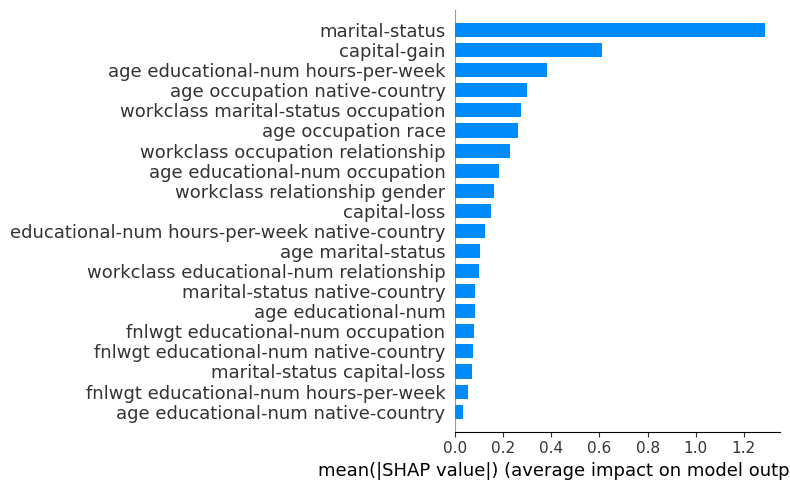

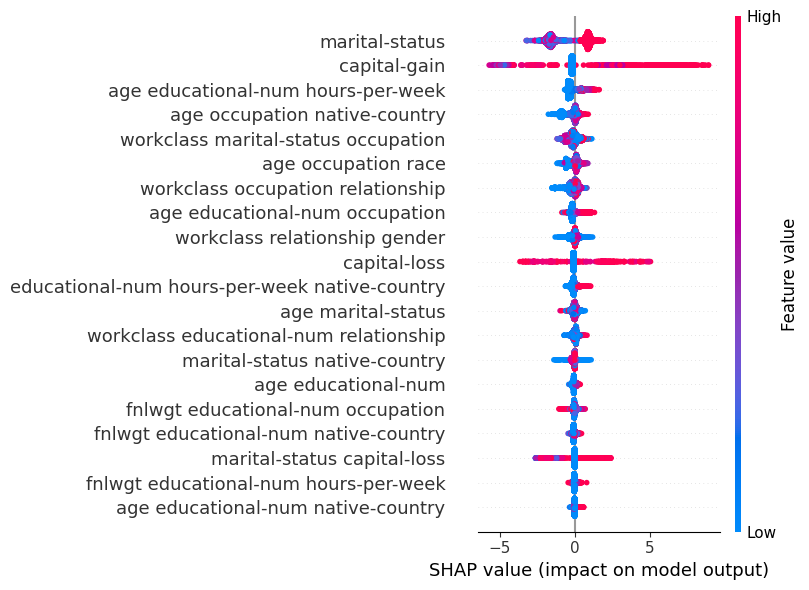

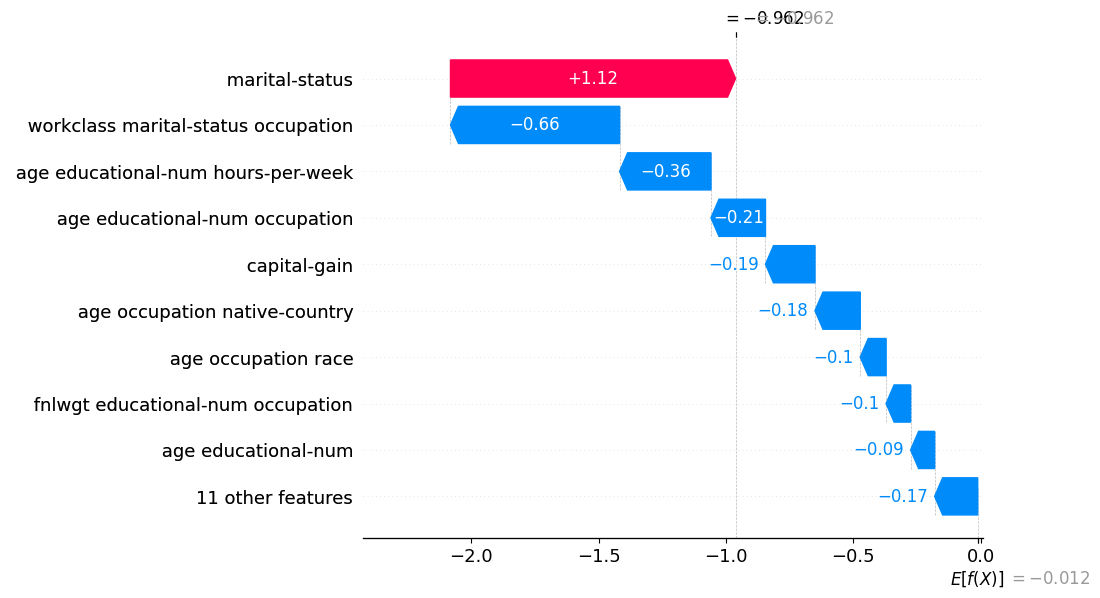

In [69]:
# --- SHAP on reduced XGBoost model (top 75 features) ---

import shap

# Create explainer
explainer_xgb_20 = shap.TreeExplainer(xgb_baseline_xgb_20)

# Compute SHAP values on test set
shap_values_xgb_20 = explainer_xgb_20.shap_values(X_test_xgb_20)

# 1. Global feature importance (bar plot)
shap.summary_plot(
    shap_values_xgb_20,
    X_test_xgb_20,
    plot_type="bar",
    plot_size=(8, 5)
)

# 2. Global direction + spread (beeswarm plot)
shap.summary_plot(
    shap_values_xgb_20,
    X_test_xgb_20,
    plot_size=(8, 6)
)

# 3. Single observation explanation
shap.plots._waterfall.waterfall_legacy(
    explainer_xgb_20.expected_value,
    shap_values_xgb_20[0],
    X_test_xgb_20.iloc[0]
)

In [70]:
# stacking tuned top-20 models using out-of-fold predictions

import numpy as np
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression

rf_oof = np.zeros(len(X_train_rf_20))
xgb_oof = np.zeros(len(X_train_xgb_20))

for train_idx, val_idx in skf.split(X_train_rf_20, y_train):
    X_tr_rf = X_train_rf_20.iloc[train_idx]
    X_val_rf = X_train_rf_20.iloc[val_idx]

    X_tr_xgb = X_train_xgb_20.iloc[train_idx]
    X_val_xgb = X_train_xgb_20.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]

    rf_fold = clone(rf_tuned_20)
    xgb_fold = clone(xgb_tuned_20)

    rf_fold.fit(X_tr_rf, y_tr)
    xgb_fold.fit(X_tr_xgb, y_tr)

    rf_oof[val_idx] = rf_fold.predict_proba(X_val_rf)[:, 1]
    xgb_oof[val_idx] = xgb_fold.predict_proba(X_val_xgb)[:, 1]

X_meta_train = np.column_stack((rf_oof, xgb_oof))

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(X_meta_train, y_train)

rf_test_meta = rf_tuned_20.predict_proba(X_test_rf_20)[:, 1]
xgb_test_meta = xgb_tuned_20.predict_proba(X_test_xgb_20)[:, 1]

X_meta_test = np.column_stack((rf_test_meta, xgb_test_meta))
stack_preds_20 = meta_model.predict(X_meta_test)

print("Stacked Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, stack_preds_20))

Stacked Top 20 Test Balanced Accuracy: 0.8095388322495674


In [71]:
# final comparison: tuned base models vs stacked model

print("Tuned RF Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_tuned_preds_20))
print("Tuned XGB Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_tuned_preds_20))
print("Stacked Top 20 Test Balanced Accuracy:", balanced_accuracy_score(y_test, stack_preds_20))

Tuned RF Top 20 Test Balanced Accuracy: 0.8263245410672397
Tuned XGB Top 20 Test Balanced Accuracy: 0.8346431596119142
Stacked Top 20 Test Balanced Accuracy: 0.8095388322495674


### MetaLearner using OOF predictions

In [72]:
# OOF Stacking Example (RF + XGB → Logistic Regression)
# standalone code cell for reuse as desired

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

# base models
rf = RandomForestClassifier(class_weight="balanced", random_state=42)
xgb = XGBClassifier(scale_pos_weight=spw, eval_metric="logloss", random_state=42)

# meta model
meta_model = LogisticRegression()

# OOF setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# store OOF predictions
rf_oof = np.zeros(len(X_train_fe))
xgb_oof = np.zeros(len(X_train_fe))

# --- Generate OOF predictions ---
for train_idx, val_idx in skf.split(X_train_fe, y_train):
    X_tr, X_val = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    
    # train base models on fold
    rf.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)
    
    # predict validation fold (probabilities for class 1)
    rf_oof[val_idx] = rf.predict_proba(X_val)[:, 1]
    xgb_oof[val_idx] = xgb.predict_proba(X_val)[:, 1]

# --- Train meta model on OOF predictions ---
X_meta_train = np.column_stack((rf_oof, xgb_oof))
meta_model.fit(X_meta_train, y_train)

# --- Retrain base models on FULL training data ---
rf.fit(X_train_fe, y_train)
xgb.fit(X_train_fe, y_train)

# --- Generate test predictions ---
rf_test = rf.predict_proba(X_test_fe)[:, 1]
xgb_test = xgb.predict_proba(X_test_fe)[:, 1]

# --- Meta model final predictions ---
X_meta_test = np.column_stack((rf_test, xgb_test))
meta_preds = meta_model.predict(X_meta_test)

# --- Evaluate ---
print("Stacked Model Balanced Accuracy:",
      balanced_accuracy_score(y_test, meta_preds))

Stacked Model Balanced Accuracy: 0.8144888491659624


In [73]:
# comparing balanced accuracy scores across adult_fe data
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))    
print("Stacked Model Test Balanced Accuracy:", balanced_accuracy_score(y_test, meta_preds))

Random Forest adult_fe Test Balanced Accuracy: 0.7834160676858406
XGBoost adult_fe Test Balanced Accuracy: 0.8410927438622955
Stacked Model Test Balanced Accuracy: 0.8144888491659624


# PyCaret

In [75]:
pip install pycaret

     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/15.8 MB 231.2 kB/s eta 0:01:07
     - ------------------------------------- 0.5/15.8 MB

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\python.exe C:\Users\prchandr\AppData\Local\Temp\1\pip-install-d_f4y1va\numpy_11aa81f8a6764231a15f67c95c4360c6\vendored-meson\meson\meson.py setup C:\Users\prchandr\AppData\Local\Temp\1\pip-install-d_f4y1va\numpy_11aa81f8a6764231a15f67c95c4360c6 C:\Users\prchandr\AppData\Local\Temp\1\pip-install-d_f4y1va\numpy_11aa81f8a6764231a15f67c95c4360c6\.mesonpy-75_ybnbx -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\prchandr\AppData\Local\Temp\1\pip-install-d_f4y1va\numpy_11aa81f8a6764231a15f67c95c4360c6\.mesonpy-75_ybnbx\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\prchandr\AppData\Local\Temp\1\pip-install-d_f4y1va\numpy_11aa81f8a6764231a15f67c95c4360c6
      Build dir: C:\Users\prchandr\App

In [79]:
import sys
!{sys.executable} -m pip install pycaret

  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\python.exe C:\Users\prchandr\AppData\Local\Temp\1\pip-install-rvpufdb4\numpy_95decdece0c84bd1837ec394847dffd2\vendored-meson\meson\meson.py setup C:\Users\prchandr\AppData\Local\Temp\1\pip-install-rvpufdb4\numpy_95decdece0c84bd1837ec394847dffd2 C:\Users\prchandr\AppData\Local\Temp\1\pip-install-rvpufdb4\numpy_95decdece0c84bd1837ec394847dffd2\.mesonpy-xw_ok_m5 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\prchandr\AppData\Local\Temp\1\pip-install-rvpufdb4\numpy_95decdece0c84bd1837ec394847dffd2\.mesonpy-xw_ok_m5\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\prchandr\AppData\Local\Temp\1\pip-install-rvpufdb4\numpy_95decdece0c84bd1837ec394847dffd2
      Build dir: C:\Users\prchandr\App

In [81]:
# PyCaret full workflow on adult_fe data
# Standalone code cell for reuse as desired

from pycaret.classification import *

# combine training features and target for PyCaret
train_fe = X_train_fe.copy()
train_fe["income"] = y_train.values

test_fe = X_test_fe.copy()
test_fe["income"] = y_test.values

# setup experiment
clf_setup = setup(
    data=train_fe,
    target="income",
    session_id=42,
    fold_strategy="stratifiedkfold",
    fold=5,
    numeric_imputation="median",
    categorical_imputation="mode",
    normalize=False,
    silent=True,
    verbose=False
)

# compare models
best_model = compare_models()

# tune best model
tuned_model = tune_model(best_model)

# optional: blend top models
blended_model = blend_models()

# optional: stack top models
stacked_model = stack_models()

# finalize chosen model (pick one: tuned_model, blended_model, or stacked_model)
final_model = finalize_model(stacked_model)

# predict on held-out test set
preds = predict_model(final_model, data=test_fe)

# show results
preds.head()

ModuleNotFoundError: No module named 'pycaret'

# GRAVEYARD

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# importing the data
adult = pd.read_csv("adult.csv")

# 1. Clean Data Values (Crucial for the Adult dataset)
# This removes leading/trailing spaces from the entries themselves
adult = adult.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. Encoding the Target Variable
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# 3. Separate Features and Target
X = adult.drop('income', axis=1)
y = adult['income']

numeric_features = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']

# 4. Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Build the Full Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42))),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 6. Stratified Split (Training/Test)
# stratify=y ensures the 25/75 split is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Stratified Cross-Validation
# shuffle=True and stratify ensures no fold is missing a class
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'feature_selection__estimator__C': [0.1, 1.0],
    'classifier__n_estimators': [100]
}



# 8. Run Workflow
grid_search = GridSearchCV(full_pipeline, param_grid, cv=skf, scoring='accuracy')
grid_search.fit(X_train, y_train)

# --- RESULTS ---
print(f"\nBest CV Accuracy: {grid_search.best_score_:.4f}")

# Identifying the "Kept" Features
selector = grid_search.best_estimator_.named_steps['feature_selection']
feature_names = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
final_features = feature_names[selector.get_support()]

print(f"Features selected by Lasso: {len(final_features)} out of {len(feature_names)}")


In [ ]:
# --- RESULTS SUMMARY ---

best_pipe = grid_search.best_estimator_

print(f"\nBest CV Accuracy: {grid_search.best_score_:.4f}")

# Extract components
selector = best_pipe.named_steps["feature_selection"]
preprocessor = best_pipe.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()
mask = selector.get_support()
final_features = feature_names[mask]

# --- 1. Encoded Features ---
print(f"\nEncoded features selected by Lasso: {len(final_features)} out of {len(feature_names)}")

print("\nSelected encoded features (first 50 shown):")
for f in final_features[:50]:
    print(f)

# --- 2. Map Back to Original Features ---
selected_original_features = set()

for f in final_features:
    if f.startswith("num__"):
        selected_original_features.add(f.replace("num__", ""))
    elif f.startswith("cat__"):
        remainder = f.replace("cat__", "", 1)
        matched = False
        for col in categorical_features:
            prefix = col + "_"
            if remainder.startswith(prefix):
                selected_original_features.add(col)
                matched = True
                break
        if not matched:
            selected_original_features.add(remainder)

all_original_features = set(numeric_features + categorical_features)

# --- 3. Clean Output for Engineering ---
print("\n\n=== ORIGINAL FEATURES KEPT ===")
for f in sorted(selected_original_features):
    print(f)

print(f"\nKept {len(selected_original_features)} out of {len(all_original_features)} original features")

# --- 4. What Was Removed ---
removed_original_features = all_original_features - selected_original_features

print("\n=== ORIGINAL FEATURES REMOVED ===")
for f in sorted(removed_original_features):
    print(f)

# --- 5. Grouped Summary (VERY useful) ---
from collections import defaultdict

grouped = defaultdict(int)

for f in final_features:
    if f.startswith("num__"):
        grouped[f.replace("num__", "")] += 1
    elif f.startswith("cat__"):
        remainder = f.replace("cat__", "", 1)
        for col in categorical_features:
            if remainder.startswith(col + "_"):
                grouped[col] += 1
                break

print("\n=== FEATURE USAGE SUMMARY ===")
for k in sorted(grouped):
    print(f"{k}: {grouped[k]} encoded features selected")

## Final Evaluation

I reduced the feature space to 20 features using averaged rankings from feature importance and permutation importance. I also attempted correlation filtering. As the number of features was reduced, model performance remained relatively stable. The full polynomial feature set did not significantly outperform the reduced top-20 feature set, indicating that most of the predictive signal was concentrated in a smaller subset of variables.

The most important predictors of income were marital status, capital gain, education level, and age, along with interaction variables between education, hours worked, and occupation. This is what we would expect as income can be attributed to multiple interacting features like human capital, work effort, and job type. Interaction terms such as age × educational-num × hours-per-week indicates that the education on income becomes stronger with experience and work intensity.

I removed features that had low importance scores or minimal contribution to model performance. Many of the polynomial and interaction features were not selected in the top 20, which suggests that they did not add significant predictive value. This is likely because tree-based models like Random Forest and XGBoost can already capture non-linear relationships without needing explicit polynomial terms.

I trained two models, Random Forest and XGBoost, and tuned their hyperparameters. Tuning resulted in modest improvements in balanced accuracy compared to the baseline models, showing that parameter optimization can improve model performance even when using a reduced feature set.

I then combined the tuned models using stacking with a logistic regression meta-learner. The stacked model showed slight improvement compared to the individual models. 

In [82]:
print(xgb_top_features)

                                           feature  feat_importance  \
5                                   marital-status         0.183118   
10                                    capital-gain         0.016123   
145             age educational-num hours-per-week         0.065675   
139                 age educational-num occupation         0.016169   
384  educational-num hours-per-week native-country         0.003465   
11                                    capital-loss         0.005300   
17                             age educational-num         0.098050   
260              fnlwgt educational-num occupation         0.002348   
146             age educational-num native-country         0.005056   
74                     marital-status capital-loss         0.003063   
266          fnlwgt educational-num hours-per-week         0.002570   
221              workclass occupation relationship         0.002138   
206         workclass educational-num relationship         0.001733   
161   

In [83]:
print(rf_top_features)

                                           feature  feat_importance  \
145             age educational-num hours-per-week         0.006524   
10                                    capital-gain         0.005900   
390       marital-status occupation hours-per-week         0.006414   
62                    educational-num relationship         0.003916   
167                age relationship native-country         0.003540   
433       occupation hours-per-week native-country         0.002920   
455               race capital-gain native-country         0.002783   
358                educational-num occupation race         0.002734   
445       relationship capital-gain native-country         0.002659   
69                       marital-status occupation         0.014108   
119                      age fnlwgt marital-status         0.002135   
414                 occupation relationship gender         0.006913   
122                                age fnlwgt race         0.002107   
77    